# Alzheimer's Disease — Recommendation System
**Machine Learning Project — MindCare**

---

### Pipeline
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training — Random Forest + Gradient Boosting
5. Feature Importance
6. Model Evaluation — Cross-Validation, ROC Curve, Confusion Matrix
7. Benchmarking — RF vs GB
8. Recommendation Demo

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Overview

In [3]:
DATA_PATH = os.path.join('..', 'data', 'alzheimers_disease_data.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}')
print(f'Patients      : {df.shape[0]}')
print(f'Columns       : {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
df.head()

Dataset shape : (2149, 35)
Patients      : 2149
Columns       : 35
Missing values: 0
Duplicates    : 0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [4]:
print('=== Target Variable ===')
print(df['Diagnosis'].value_counts().rename({0: 'Healthy (0)', 1: "Alzheimer's (1)"}))
print(f'\nClass ratio: {df["Diagnosis"].value_counts(normalize=True).round(3).to_dict()}')

=== Target Variable ===
Diagnosis
Healthy (0)        1389
Alzheimer's (1)     760
Name: count, dtype: int64

Class ratio: {0: 0.646, 1: 0.354}


In [5]:
FEATURE_COLS = [
    'Age', 'Gender', 'Ethnicity', 'EducationLevel',
    'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension',
    'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL',
    'CholesterolHDL', 'CholesterolTriglycerides',
    'MMSE', 'FunctionalAssessment', 'MemoryComplaints',
    'BehavioralProblems', 'ADL',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness',
]

print(f'Total features used: {len(FEATURE_COLS)}')
print(df[FEATURE_COLS].describe().round(2))

Total features used: 32
           Age   Gender  Ethnicity  EducationLevel      BMI  Smoking  \
count  2149.00  2149.00     2149.0         2149.00  2149.00  2149.00   
mean     74.91     0.51        0.7            1.29    27.66     0.29   
std       8.99     0.50        1.0            0.90     7.22     0.45   
min      60.00     0.00        0.0            0.00    15.01     0.00   
25%      67.00     0.00        0.0            1.00    21.61     0.00   
50%      75.00     1.00        0.0            1.00    27.82     0.00   
75%      83.00     1.00        1.0            2.00    33.87     1.00   
max      90.00     1.00        3.0            3.00    39.99     1.00   

       AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
count             2149.00           2149.00      2149.00       2149.00  ...   
mean                10.04              4.92         4.99          7.05  ...   
std                  5.76              2.86         2.91          1.76  ...   
min        

---
## 2. Exploratory Data Analysis (EDA)

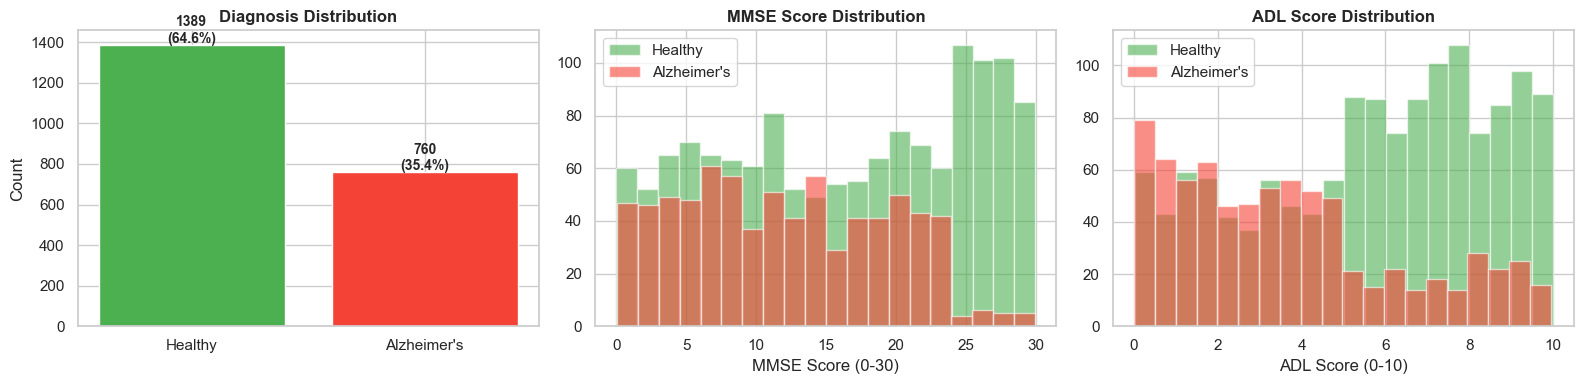

In [6]:
# Diagnosis distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['Diagnosis'].value_counts()
axes[0].bar(["Healthy", "Alzheimer's"], counts.values, color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Diagnosis Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# MMSE by diagnosis
df[df['Diagnosis']==0]['MMSE'].hist(ax=axes[1], alpha=0.6, color='#4CAF50', label='Healthy', bins=20)
df[df['Diagnosis']==1]['MMSE'].hist(ax=axes[1], alpha=0.6, color='#F44336', label="Alzheimer's", bins=20)
axes[1].set_title('MMSE Score Distribution', fontweight='bold')
axes[1].set_xlabel('MMSE Score (0-30)')
axes[1].legend()

# ADL by diagnosis
df[df['Diagnosis']==0]['ADL'].hist(ax=axes[2], alpha=0.6, color='#4CAF50', label='Healthy', bins=20)
df[df['Diagnosis']==1]['ADL'].hist(ax=axes[2], alpha=0.6, color='#F44336', label="Alzheimer's", bins=20)
axes[2].set_title('ADL Score Distribution', fontweight='bold')
axes[2].set_xlabel('ADL Score (0-10)')
axes[2].legend()

plt.tight_layout()
plt.show()

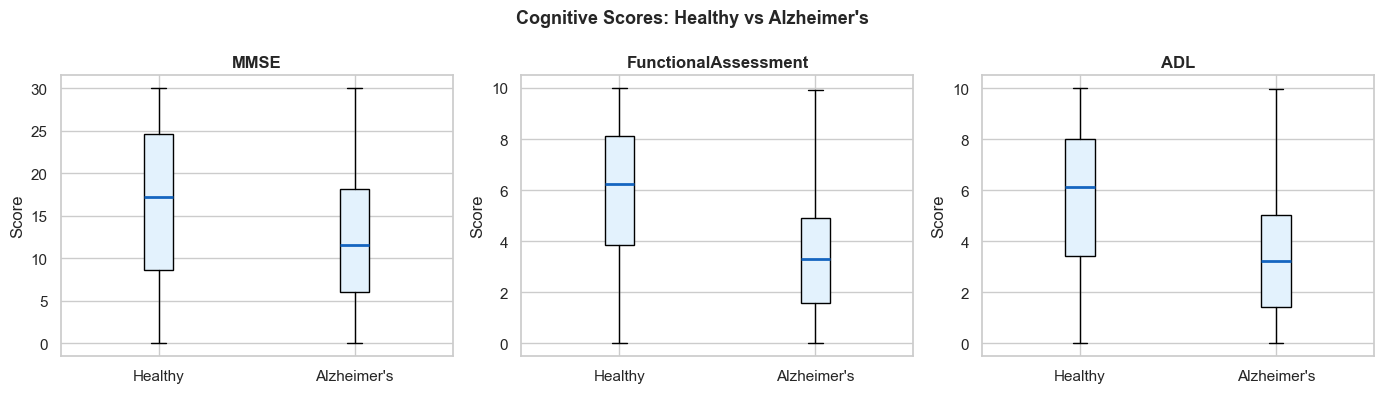

In [7]:
# Cognitive features comparison
cognitive = ['MMSE', 'FunctionalAssessment', 'ADL']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(cognitive):
    data_healthy = df[df['Diagnosis']==0][col]
    data_alz     = df[df['Diagnosis']==1][col]
    axes[i].boxplot([data_healthy, data_alz], labels=['Healthy', "Alzheimer's"],
                    patch_artist=True,
                    boxprops=dict(facecolor='#e3f2fd'),
                    medianprops=dict(color='#1565c0', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Score')

plt.suptitle('Cognitive Scores: Healthy vs Alzheimer\'s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

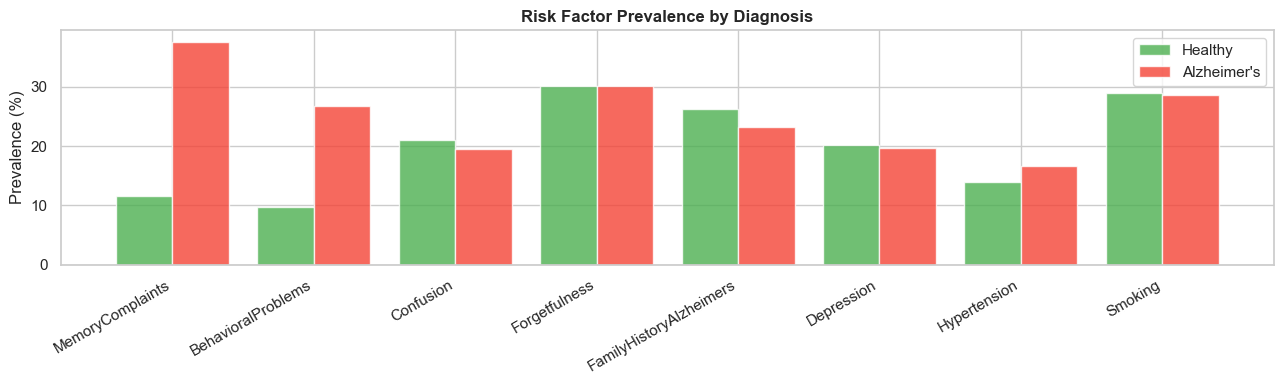

In [8]:
# Binary risk factors prevalence
binary_cols = [
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Forgetfulness',
    'FamilyHistoryAlzheimers', 'Depression', 'Hypertension', 'Smoking'
]

prev_healthy = df[df['Diagnosis']==0][binary_cols].mean() * 100
prev_alz     = df[df['Diagnosis']==1][binary_cols].mean() * 100

x = np.arange(len(binary_cols))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 0.2, prev_healthy, 0.4, label='Healthy', color='#4CAF50', alpha=0.8)
ax.bar(x + 0.2, prev_alz,     0.4, label="Alzheimer's", color='#F44336', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(binary_cols, rotation=30, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Risk Factor Prevalence by Diagnosis', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

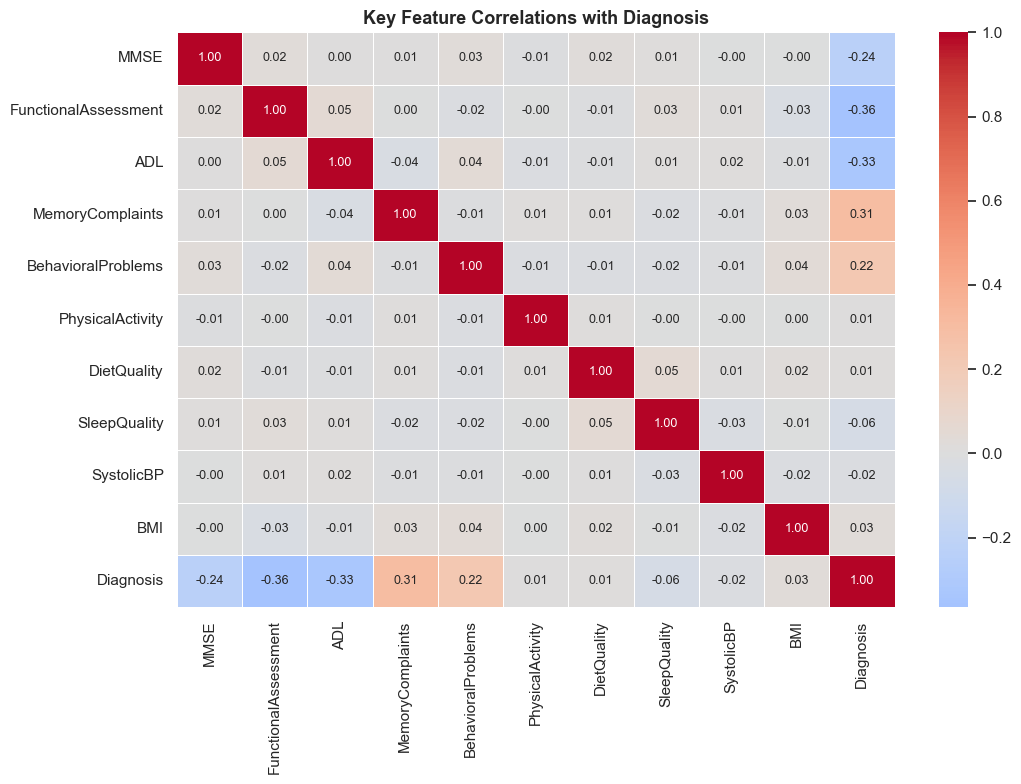

Top features correlated with Diagnosis:
FunctionalAssessment    0.365
ADL                     0.332
MemoryComplaints        0.307
MMSE                    0.237
BehavioralProblems      0.224
SleepQuality            0.057
BMI                     0.026
SystolicBP              0.016
Name: Diagnosis, dtype: float64


In [9]:
# Correlation heatmap — key features
key_feats = ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints',
             'BehavioralProblems', 'PhysicalActivity', 'DietQuality',
             'SleepQuality', 'SystolicBP', 'BMI', 'Diagnosis']

plt.figure(figsize=(11, 8))
corr = df[key_feats].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Key Feature Correlations with Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features correlated with Diagnosis:')
print(corr['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False).head(8).round(3))

---
## 3. Preprocessing
- **StandardScaler**: normalize all features to mean=0, std=1
- **Healthy baseline**: compute mean & std from non-diagnosed patients only (used for recommendation contribution scoring)

In [10]:
X = df[FEATURE_COLS].values
y = df['Diagnosis'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix : {X_scaled.shape}')
print(f'Mean (scaled)  : {X_scaled.mean():.6f}  (expected ~0)')
print(f'Std  (scaled)  : {X_scaled.std():.6f}  (expected ~1)')
print(f'Class balance  : {np.bincount(y)} (healthy / alzheimers)')

Feature matrix : (2149, 32)
Mean (scaled)  : -0.000000  (expected ~0)
Std  (scaled)  : 1.000000  (expected ~1)
Class balance  : [1389  760] (healthy / alzheimers)


In [11]:
# Healthy baseline — computed from non-diagnosed patients only
healthy_df   = df[df['Diagnosis'] == 0][FEATURE_COLS]
healthy_mean = healthy_df.mean()
healthy_std  = healthy_df.std()

print(f'Healthy baseline computed from {len(healthy_df)} non-diagnosed patients')
print('\nHealthy averages (top cognitive/lifestyle features):')
key_show = ['MMSE', 'FunctionalAssessment', 'ADL', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'BMI', 'SystolicBP']
pd.DataFrame({'Healthy Mean': healthy_mean[key_show].round(2), 'Healthy Std': healthy_std[key_show].round(2)})

Healthy baseline computed from 1389 non-diagnosed patients

Healthy averages (top cognitive/lifestyle features):


,Healthy Mean,Healthy Std
MMSE,16.27,8.93
FunctionalAssessment,5.86,2.76
ADL,5.71,2.83
PhysicalActivity,4.91,2.87
DietQuality,4.97,2.91
SleepQuality,7.12,1.76
BMI,27.52,7.17
SystolicBP,134.56,25.95


---
## 4. Model Training — Random Forest + Gradient Boosting

**Why these two models?**
- Both are state-of-the-art for tabular/clinical data
- Both provide **feature importance** (essential for ranking recommendations)
- They are complementary: RF reduces variance, GB reduces bias
- Averaging their probabilities (ensemble) gives a more stable prediction

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest (5-fold CV)...')
rf_auc = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc')
rf_acc = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
print(f'  AUC  : {rf_auc.mean():.4f} +/- {rf_auc.std():.4f}')
print(f'  Acc  : {rf_acc.mean():.4f} +/- {rf_acc.std():.4f}')
rf.fit(X_scaled, y)
print('  Done.')

Training Random Forest (5-fold CV)...
  AUC  : 0.9524 +/- 0.0068
  Acc  : 0.9493 +/- 0.0060
  Done.


In [15]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

print('Training Gradient Boosting (5-fold CV)...')
gb_auc = cross_val_score(gb, X_scaled, y, cv=cv, scoring='roc_auc')
gb_acc = cross_val_score(gb, X_scaled, y, cv=cv, scoring='accuracy')
print(f'  AUC  : {gb_auc.mean():.4f} +/- {gb_auc.std():.4f}')
print(f'  Acc  : {gb_acc.mean():.4f} +/- {gb_acc.std():.4f}')
gb.fit(X_scaled, y)
print('  Done.')

Training Gradient Boosting (5-fold CV)...
  AUC  : 0.9487 +/- 0.0108
  Acc  : 0.9525 +/- 0.0043
  Done.


In [16]:
# Ensemble predictions
y_prob_rf  = rf.predict_proba(X_scaled)[:, 1]
y_prob_gb  = gb.predict_proba(X_scaled)[:, 1]
y_prob_ens = (y_prob_rf + y_prob_gb) / 2
y_pred_ens = (y_prob_ens >= 0.5).astype(int)

print('=== Ensemble (RF + GB) — Full Train Metrics ===')
print(f'AUC      : {roc_auc_score(y, y_prob_ens):.4f}')
print(f'Accuracy : {accuracy_score(y, y_pred_ens):.4f}')
print()
print(classification_report(y, y_pred_ens, target_names=["Healthy", "Alzheimer's"]))

=== Ensemble (RF + GB) — Full Train Metrics ===
AUC      : 0.9984
Accuracy : 0.9716

              precision    recall  f1-score   support

     Healthy       0.97      0.98      0.98      1389
 Alzheimer's       0.97      0.95      0.96       760

    accuracy                           0.97      2149
   macro avg       0.97      0.97      0.97      2149
weighted avg       0.97      0.97      0.97      2149



---
## 5. Feature Importance

In [17]:
rf_imp  = pd.Series(rf.feature_importances_,  index=FEATURE_COLS)
gb_imp  = pd.Series(gb.feature_importances_,  index=FEATURE_COLS)
avg_imp = ((rf_imp + gb_imp) / 2).sort_values(ascending=False)

print('Top 10 features (ensemble importance):')
for feat, imp in avg_imp.head(10).items():
    print(f'  {feat:<30} {imp:.4f}')

Top 10 features (ensemble importance):
  FunctionalAssessment           0.2300
  ADL                            0.2219
  MMSE                           0.1907
  MemoryComplaints               0.1172
  BehavioralProblems             0.0863
  DietQuality                    0.0157
  CholesterolHDL                 0.0136
  PhysicalActivity               0.0131
  CholesterolTriglycerides       0.0126
  CholesterolTotal               0.0125


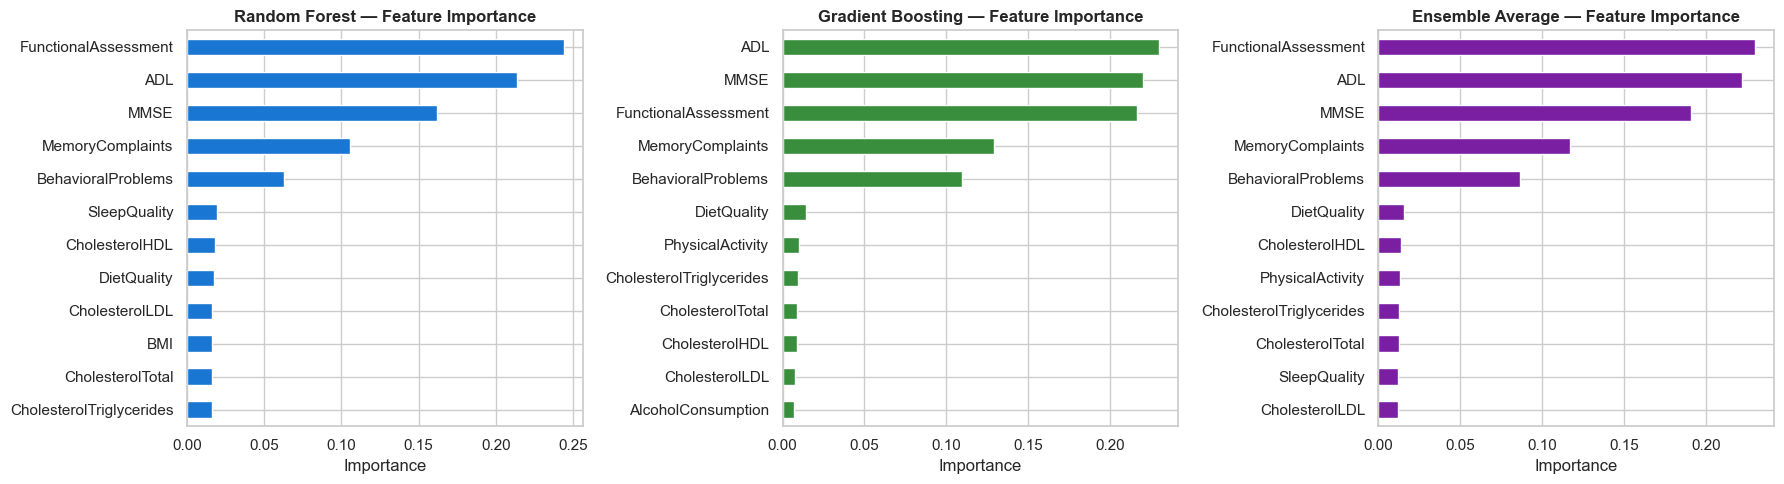

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RF importance
rf_imp.sort_values().tail(12).plot(kind='barh', ax=axes[0], color='#1976D2')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

# GB importance
gb_imp.sort_values().tail(12).plot(kind='barh', ax=axes[1], color='#388E3C')
axes[1].set_title('Gradient Boosting — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

# Ensemble average
avg_imp.sort_values().tail(12).plot(kind='barh', ax=axes[2], color='#7B1FA2')
axes[2].set_title('Ensemble Average — Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

---
## 6. Model Evaluation — ROC Curve & Confusion Matrix

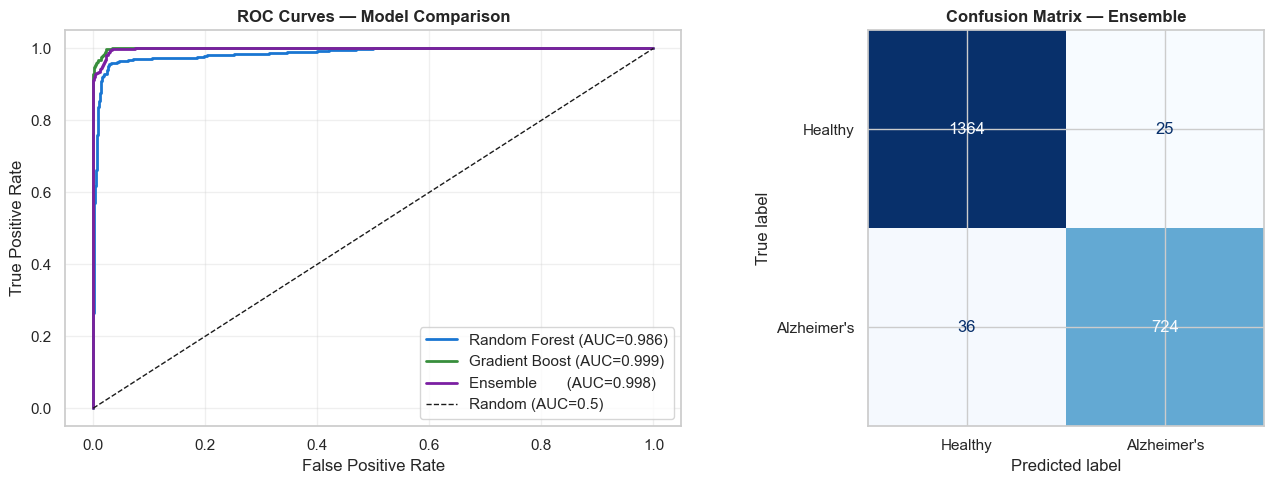

In [19]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for probs, label, color in [
    (y_prob_rf,  f'Random Forest (AUC={roc_auc_score(y, y_prob_rf):.3f})',  '#1976D2'),
    (y_prob_gb,  f'Gradient Boost (AUC={roc_auc_score(y, y_prob_gb):.3f})', '#388E3C'),
    (y_prob_ens, f'Ensemble       (AUC={roc_auc_score(y, y_prob_ens):.3f})', '#7B1FA2'),
]:
    fpr, tpr, _ = roc_curve(y, probs)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix — Ensemble
cm = confusion_matrix(y, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Alzheimer's"])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Ensemble', fontweight='bold')

plt.tight_layout()
plt.show()

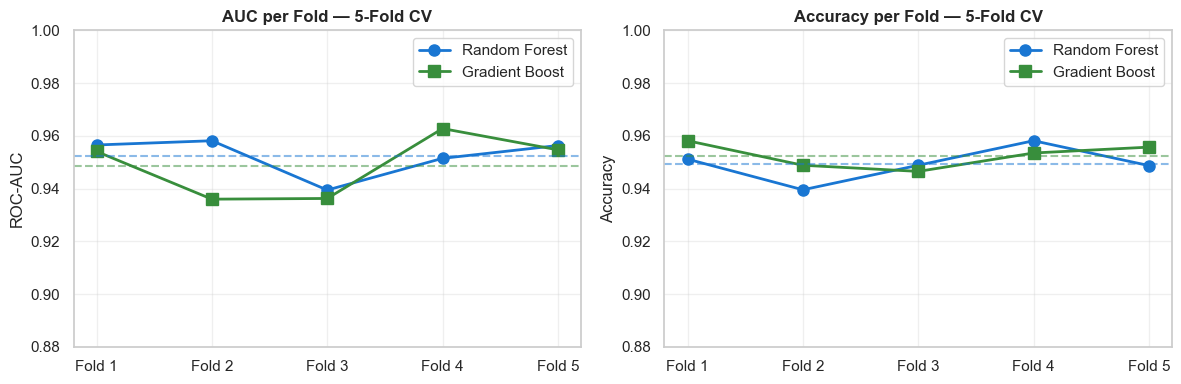

In [20]:
# Cross-validation scores per fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)

axes[0].plot(folds, rf_auc, 'o-', color='#1976D2', linewidth=2, markersize=8, label='Random Forest')
axes[0].plot(folds, gb_auc, 's-', color='#388E3C', linewidth=2, markersize=8, label='Gradient Boost')
axes[0].axhline(rf_auc.mean(), color='#1976D2', linestyle='--', alpha=0.5)
axes[0].axhline(gb_auc.mean(), color='#388E3C', linestyle='--', alpha=0.5)
axes[0].set_title('AUC per Fold — 5-Fold CV', fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim([0.88, 1.0])
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(folds, rf_acc, 'o-', color='#1976D2', linewidth=2, markersize=8, label='Random Forest')
axes[1].plot(folds, gb_acc, 's-', color='#388E3C', linewidth=2, markersize=8, label='Gradient Boost')
axes[1].axhline(rf_acc.mean(), color='#1976D2', linestyle='--', alpha=0.5)
axes[1].axhline(gb_acc.mean(), color='#388E3C', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy per Fold — 5-Fold CV', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.88, 1.0])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Benchmarking — RF vs GB

In [21]:
benchmarking = pd.DataFrame({
    'Metric'              : ['CV AUC (mean)', 'CV AUC (std)', 'CV Accuracy', 'Train AUC', 'Train Accuracy'],
    'Random Forest'       : [
        round(rf_auc.mean(), 4),
        round(rf_auc.std(),  4),
        round(rf_acc.mean(), 4),
        round(roc_auc_score(y, y_prob_rf), 4),
        round(accuracy_score(y, rf.predict(X_scaled)), 4),
    ],
    'Gradient Boosting'   : [
        round(gb_auc.mean(), 4),
        round(gb_auc.std(),  4),
        round(gb_acc.mean(), 4),
        round(roc_auc_score(y, y_prob_gb), 4),
        round(accuracy_score(y, gb.predict(X_scaled)), 4),
    ],
    'Ensemble (RF+GB)'    : [
        '-', '-', '-',
        round(roc_auc_score(y, y_prob_ens), 4),
        round(accuracy_score(y, y_pred_ens), 4),
    ],
})

print('=== Benchmarking Table ===')
benchmarking

=== Benchmarking Table ===


,Metric,Random Forest,Gradient Boosting,Ensemble (RF+GB)
0,CV AUC (mean),0.9524,0.9487,-
1,CV AUC (std),0.0068,0.0108,-
2,CV Accuracy,0.9493,0.9525,-
3,Train AUC,0.9863,0.9992,0.9984
4,Train Accuracy,0.9595,0.9805,0.9716


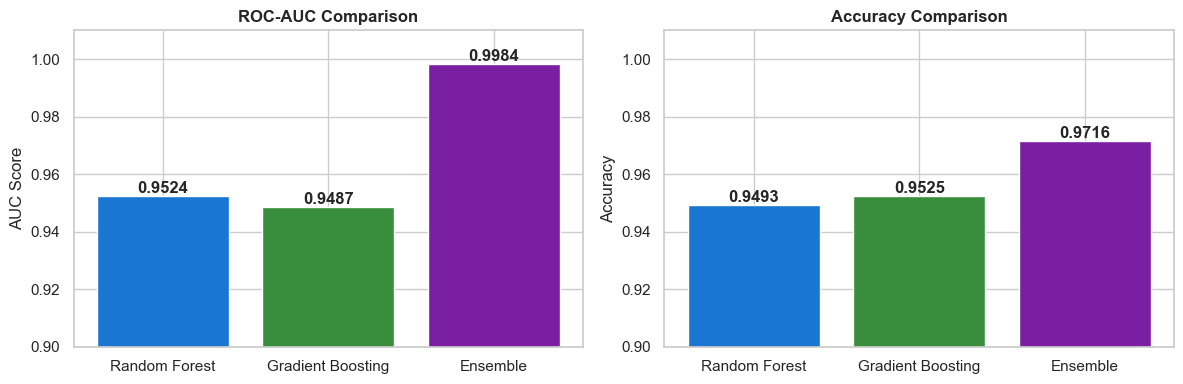

Best model by CV AUC: Random Forest


In [22]:
# Visual benchmarking
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['Random Forest', 'Gradient Boosting', 'Ensemble']
aucs   = [rf_auc.mean(), gb_auc.mean(), roc_auc_score(y, y_prob_ens)]
accs   = [rf_acc.mean(), gb_acc.mean(), accuracy_score(y, y_pred_ens)]
colors = ['#1976D2', '#388E3C', '#7B1FA2']

bars1 = axes[0].bar(models, aucs, color=colors, edgecolor='white')
axes[0].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylabel('AUC Score')
axes[0].set_ylim([0.9, 1.01])
for bar, val in zip(bars1, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(models, accs, color=colors, edgecolor='white')
axes[1].set_title('Accuracy Comparison', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.9, 1.01])
for bar, val in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

best = 'Random Forest' if rf_auc.mean() >= gb_auc.mean() else 'Gradient Boosting'
print(f'Best model by CV AUC: {best}')

In [23]:
# Forces / Faiblesses
summary = pd.DataFrame({
    'Criterion'          : ['Training', 'Overfitting risk', 'Stability (CV std)', 'Interpretability', 'Best use case'],
    'Random Forest'      : ['Fast (parallel trees)', 'Low', f'{rf_auc.std():.4f} (more stable)', 'Feature importance', 'Robust baseline'],
    'Gradient Boosting'  : ['Slower (sequential)', 'Medium', f'{gb_auc.std():.4f}', 'Feature importance', 'Complex patterns'],
})
print('=== Forces / Faiblesses ===')
summary

=== Forces / Faiblesses ===


,Criterion,Random Forest,Gradient Boosting
0,Training,Fast (parallel trees),Slower (sequential)
1,Overfitting risk,Low,Medium
2,Stability (CV std),0.0068 (more stable),0.0108
3,Interpretability,Feature importance,Feature importance
4,Best use case,Robust baseline,Complex patterns


---
## 8. Recommendation Demo

How recommendations are generated:
1. Patient features → StandardScaler
2. RF + GB → ensemble risk score (0–100)
3. Per-feature contribution = `feature_importance × deviation_from_healthy_mean / std`
4. Top contributors → High/Medium/Low priority
5. Template filled with patient's actual value

In [24]:
import sys
sys.path.insert(0, '..')
from model.recommender import recommend

# High-risk patient
patient_high = {
    'Age': 75, 'Gender': 1, 'Ethnicity': 0, 'EducationLevel': 1,
    'BMI': 29.5, 'Smoking': 1, 'AlcoholConsumption': 10,
    'PhysicalActivity': 1.2, 'DietQuality': 3.0, 'SleepQuality': 5.0,
    'FamilyHistoryAlzheimers': 1, 'CardiovascularDisease': 1, 'Diabetes': 0,
    'Depression': 1, 'HeadInjury': 0, 'Hypertension': 1,
    'SystolicBP': 145, 'DiastolicBP': 90, 'CholesterolTotal': 240,
    'CholesterolLDL': 160, 'CholesterolHDL': 35, 'CholesterolTriglycerides': 220,
    'MMSE': 20, 'FunctionalAssessment': 4, 'MemoryComplaints': 1,
    'BehavioralProblems': 1, 'ADL': 4,
    'Confusion': 1, 'Disorientation': 1, 'PersonalityChanges': 1,
    'DifficultyCompletingTasks': 1, 'Forgetfulness': 1
}

result = recommend(patient_high)

print(f'Risk Score : {result["risk_score"]} / 100')
print(f'Risk Label : {result["risk_label"]}')
print(f'RF Prob    : {result["prob_rf"]}%')
print(f'GB Prob    : {result["prob_gb"]}%')
print(f'Total Recs : {result["total_recommendations"]}')
print()
print('Top 3 Risk Drivers:')
for d in result['risk_drivers']:
    print(f'  {d["feature"]:<25} contribution={d["contribution"]:.4f}  patient={d["patient_value"]}  healthy_avg={d["healthy_avg"]}')

Risk Score : 100.0 / 100
Risk Label : High Risk
RF Prob    : 89.9%
GB Prob    : 99.5%
Total Recs : 19

Top 3 Risk Drivers:
  FunctionalAssessment      contribution=0.1550  patient=4  healthy_avg=5.86
  ADL                       contribution=0.1341  patient=4  healthy_avg=5.71
  MemoryComplaints          contribution=0.1172  patient=1  healthy_avg=0.12


In [25]:
# Display recommendations as a styled table
recs_df = pd.DataFrame(result['recommendations'])[
    ['priority', 'category', 'recommendation', 'contribution_score', 'patient_value', 'healthy_avg', 'detail']
].round({'contribution_score': 4, 'healthy_avg': 2})

def color_priority(val):
    colors = {'High': 'background-color:#ffcccc', 'Medium': 'background-color:#fff3cc', 'Low': 'background-color:#ccffcc'}
    return colors.get(val, '')

recs_df.style.applymap(color_priority, subset=['priority'])

,priority,category,recommendation,contribution_score,patient_value,healthy_avg,detail
0,High,Cognitive,Functional Rehabilitation,0.155000,4.000000,5.860000,Functional assessment 4.0/10 (healthy avg: 5.9). Physiotherapy and structured daily routine recommended.
1,High,Cognitive,Daily Living Support,0.134100,4.000000,5.710000,ADL 4.0/10 (healthy avg: 5.7). Occupational therapy and in-home care assessment recommended.
2,High,Cognitive,Memory Clinic Referral,0.117200,1.000000,0.120000,Subjective memory complaints warrant comprehensive neuropsychological assessment to distinguish normal aging from MCI.
3,High,Mental Health,Behavioral Management,0.086300,1.000000,0.100000,"Behavioral symptoms can be managed through structured routines, music therapy, and caregiver training."
4,High,Lifestyle,Increase Physical Activity,0.016900,1.200000,4.910000,1.2h/week recorded (healthy avg: 4.9h/week). Aim for at least 2.5h/week of moderate aerobic exercise.
5,Medium,Lifestyle,Sleep Quality Improvement,0.014800,5.000000,7.120000,Sleep quality 5.0/10 (healthy avg: 7.1/10). Poor sleep is linked to amyloid buildup. Evaluate for sleep apnea.
6,Medium,Clinical,Increase HDL Cholesterol,0.014000,35.000000,58.730000,HDL 35 mg/dL (healthy avg: 59). Aerobic exercise and omega-3 supplementation recommended.
7,Medium,Lifestyle,Dietary Improvement,0.010700,3.000000,4.970000,Diet quality 3.0/10 (healthy avg: 5.0/10). Mediterranean diet recommended — shown to slow cognitive decline.
8,Medium,Clinical,LDL Cholesterol Management,0.009500,160.000000,125.360000,LDL 160 mg/dL (healthy avg: 125). Dietary changes and possible statin therapy recommended.
9,Medium,Clinical,Blood Pressure Management,0.003400,145.000000,134.560000,BP 145/90 mmHg (healthy avg: 135/90). Hypertension is a major modifiable dementia risk factor.


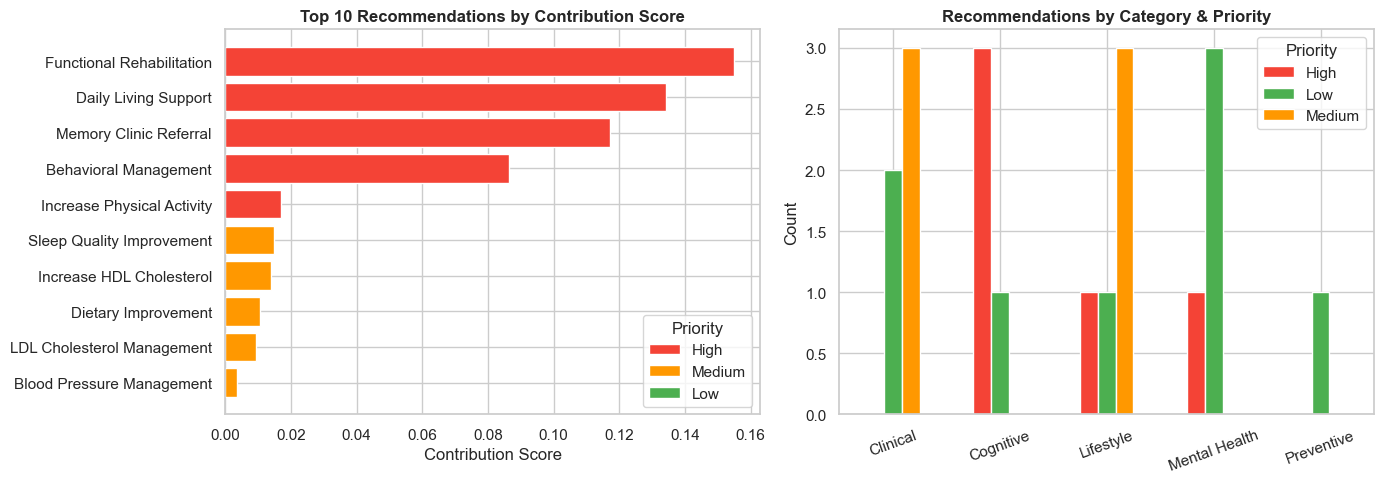

In [26]:
# Recommendations: contribution score chart
recs_plot = pd.DataFrame(result['recommendations']).head(10)
colors_map = {'High': '#F44336', 'Medium': '#FF9800', 'Low': '#4CAF50'}
bar_colors = [colors_map[p] for p in recs_plot['priority']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(recs_plot['recommendation'], recs_plot['contribution_score'], color=bar_colors)
axes[0].set_xlabel('Contribution Score')
axes[0].set_title('Top 10 Recommendations by Contribution Score', fontweight='bold')
axes[0].invert_yaxis()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='High'), Patch(facecolor='#FF9800', label='Medium'), Patch(facecolor='#4CAF50', label='Low')]
axes[0].legend(handles=legend_elements, title='Priority')

# By category
cat_counts = pd.DataFrame(result['recommendations']).groupby(['category', 'priority']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', ax=axes[1], color=['#F44336', '#4CAF50', '#FF9800'], edgecolor='white')
axes[1].set_title('Recommendations by Category & Priority', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Priority')

plt.tight_layout()
plt.show()

In [27]:
# Compare low-risk vs high-risk patient
patient_low = {
    'Age': 65, 'Gender': 0, 'Ethnicity': 0, 'EducationLevel': 3,
    'BMI': 22.0, 'Smoking': 0, 'AlcoholConsumption': 2,
    'PhysicalActivity': 6.0, 'DietQuality': 8.5, 'SleepQuality': 8.5,
    'FamilyHistoryAlzheimers': 0, 'CardiovascularDisease': 0, 'Diabetes': 0,
    'Depression': 0, 'HeadInjury': 0, 'Hypertension': 0,
    'SystolicBP': 110, 'DiastolicBP': 70, 'CholesterolTotal': 160,
    'CholesterolLDL': 80, 'CholesterolHDL': 75, 'CholesterolTriglycerides': 100,
    'MMSE': 29, 'FunctionalAssessment': 9, 'MemoryComplaints': 0,
    'BehavioralProblems': 0, 'ADL': 9.5,
    'Confusion': 0, 'Disorientation': 0, 'PersonalityChanges': 0,
    'DifficultyCompletingTasks': 0, 'Forgetfulness': 0
}

result_low = recommend(patient_low)

comparison = pd.DataFrame({
    'Metric'          : ['Risk Score', 'Risk Label', 'RF Probability', 'GB Probability', 'Total Recommendations'],
    'Healthy Patient' : [result_low['risk_score'], result_low['risk_label'], f"{result_low['prob_rf']}%", f"{result_low['prob_gb']}%", result_low['total_recommendations']],
    'High-Risk Patient': [result['risk_score'], result['risk_label'], f"{result['prob_rf']}%", f"{result['prob_gb']}%", result['total_recommendations']],
})

print('=== Patient Comparison ===')
comparison

=== Patient Comparison ===


,Metric,Healthy Patient,High-Risk Patient
0,Risk Score,5.5,100.0
1,Risk Label,Low Risk,High Risk
2,RF Probability,9.7%,89.9%
3,GB Probability,1.3%,99.5%
4,Total Recommendations,0,19


---
## Summary

| Metric | Value |
|--------|-------|
| Dataset | 2,149 patients, 32 features |
| Healthy baseline | 1,389 non-diagnosed patients |
| Random Forest CV AUC | **0.9524** |
| Gradient Boosting CV AUC | **0.9487** |
| Ensemble Train Accuracy | **97.16%** |
| Best model | **Random Forest** |
| Top feature | FunctionalAssessment (0.23) |
| Recommendation templates | 24 features |

**Conclusion:** The RF+GB ensemble provides a robust 0–100 risk score grounded in clinical data. Recommendations are fully personalized — ranked by each feature's contribution relative to a healthy population baseline, with no hardcoded rules.